# Six-method mapped-minus-full deoxygenation maps

Produce `Figures/all_models_multimodel_mean_mapped_minus_full_deoxygenation_difference_maps_1965_2021.pdf`. Run the six-method cache notebook first.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import xarray as xr


SOURCE = Path('/scratch/gpfs/LRGROUP/db9274/Subsampled_o2_variability/Cause_model_obs_differences/Figures')
OUTPUT = Path.cwd() / 'Figures'
STEM = 'all_models_multimodel_mean_mapped_minus_full_deoxygenation_difference_maps_1965_2021'
DEPTHS = {'Upper 2000 m': 'upper_2000_m', 'Below 2000 m': 'below_2000_m'}
OLIVELLI_LABEL = 'Olivelli et al. (2026)'
TITLE_LABELS = {
    'Ito et al. (2024): NN': 'Ito et al. (2024):\nNeural network',
    'Ito et al. (2024): RF': 'Ito et al. (2024):\nRandom forest',
}
CENTRAL_LONGITUDE = 205
SEAM_LONGITUDES = (71.5, 72.5, 73.5, 74.5)
MAX_SEAM_GAP_DEGREES = 80.0


def normalized_longitudes(x, longitudes, dx):
    targets = []
    for lon in longitudes:
        target = float(lon)
        while target < float(x.min()):
            target += 360.0
        while target > float(x.max()) + dx:
            target -= 360.0
        targets.append(target)
    return targets


def contiguous_native_groups(x, targets, dx):
    native = sorted(float(x[np.argmin(np.abs(x - target))])
                    for target in targets if np.any(np.isclose(x, target)))
    groups = []
    for lon in native:
        if not groups or not np.isclose(lon - groups[-1][-1], dx):
            groups.append([lon])
        else:
            groups[-1].append(lon)
    return groups


def fill_native_group(field, x, group):
    result = field.copy()
    values = np.array(result.values, copy=True)
    x_axis = result.get_axis_num('x')
    moved = np.moveaxis(values, x_axis, -1)
    indices = [int(np.argmin(np.abs(x - lon))) for lon in group]
    start, end, nx = min(indices), max(indices), len(x)
    for lead_index in np.ndindex(moved.shape[:-1]):
        row = moved[lead_index]
        search = row.copy()
        search[indices] = np.nan
        left = next((idx for step in range(1, nx)
                     if np.isfinite(search[idx := (start - step) % nx])), None)
        right = next((idx for step in range(1, nx)
                      if np.isfinite(search[idx := (end + step) % nx])), None)
        if left is None or right is None:
            continue
        left_x, right_x = float(x[left]), float(x[right])
        if right <= left:
            right_x += 360.0
        span = right_x - left_x
        if span <= 0 or span > MAX_SEAM_GAP_DEGREES:
            continue
        for idx in indices:
            if np.isfinite(row[idx]):
                continue
            target = float(x[idx]) + (360.0 if idx <= left else 0.0)
            weight = (target - left_x) / span
            row[idx] = row[left] + weight * (row[right] - row[left])
    result.values = np.moveaxis(moved, -1, x_axis)
    return result


def fill_indian_ocean_seam(field):
    x = np.asarray(field.x, dtype=float)
    dx = float(np.nanmedian(np.diff(x)))
    targets = normalized_longitudes(x, SEAM_LONGITUDES, dx)
    result = field.copy()
    for group in contiguous_native_groups(x, targets, dx):
        result = fill_native_group(result, x, group)
    return result


def add_cyclic(field):
    x = np.asarray(field.x, dtype=float)
    dx = float(np.nanmedian(np.diff(x)))
    first = field.isel(x=0).assign_coords(x=field.x.isel(x=-1) + dx)
    return xr.concat([field, first], dim='x')


def stipple(ax, mask, transform):
    sampled = add_cyclic(mask).isel(y=slice(None, None, 3), x=slice(None, None, 3))
    values = np.asarray(sampled)
    yy, xx = np.where(np.isfinite(values) & values.astype(bool))
    if len(xx):
        ax.scatter(sampled.x.values[xx], sampled.y.values[yy], transform=transform,
                   s=2.4, c='k', marker='.', linewidths=0, alpha=0.68, zorder=4)


def main():
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    cache = SOURCE / 'all_models_multimodel_mean_mapped_minus_full_deoxygenation_difference_maps_1965_2021.nc'
    with xr.open_dataset(cache) as source:
        base = source.load()

    # The original cache contains the five existing products, including Ito RF.
    # Add the independently cached Olivelli upper/deep maps as a sixth product.
    olivelli_cache = Path.cwd() / 'Figures/cache_six_method_maps_1965_2021/observation_olivelli_2026.nc'
    with xr.open_dataset(olivelli_cache) as source:
        olivelli = source.load()
    olivelli_difference = xr.concat(
        [olivelli[depth_key] for depth_key in DEPTHS.values()],
        dim=xr.IndexVariable('depth', list(DEPTHS.values())),
    ).expand_dims(product=[OLIVELLI_LABEL])
    data = xr.concat(
        [base['difference'].sel(depth=list(DEPTHS.values())), olivelli_difference],
        dim='product',
    )
    gain = xr.concat(
        [base['oxygen_gain'].sel(depth=list(DEPTHS.values())),
         xr.full_like(olivelli_difference, False, dtype=bool)],
        dim='product',
    )
    finite = data.values[np.isfinite(data.values)]
    limit = max(abs(np.nanpercentile(finite, 2)), abs(np.nanpercentile(finite, 98)), 0.05)

    figure_width = 8.0
    figure_height = 5.3
    projection = ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE)
    transform = ccrs.PlateCarree()
    products = [str(v) for v in data.product.values]
    fig, axes = plt.subplots(3, 4, figsize=(figure_width, figure_height),
                             subplot_kw={'projection': projection})
    fig.subplots_adjust(left=0.01, right=0.99, top=0.90, bottom=0.19,
                        wspace=0.04, hspace=0.22)
    invalid_cmap = ListedColormap(['0.86'])

    last = None
    for row in range(3):
        for col in range(4):
            product_index = row * 2 + (col % 2)
            product = products[product_index]
            depth_key = list(DEPTHS.values())[col // 2]
            ax = axes[row, col]
            field = add_cyclic(fill_indian_ocean_seam(data.sel(product=product, depth=depth_key)))
            invalid = xr.where(np.isfinite(field), np.nan, 1.0)
            invalid.plot.pcolormesh(ax=ax, transform=transform, cmap=invalid_cmap,
                                    vmin=0, vmax=1, add_colorbar=False, rasterized=True, zorder=1)
            last = field.plot.pcolormesh(ax=ax, transform=transform, cmap='bwr',
                                         vmin=-limit, vmax=limit, add_colorbar=False,
                                         rasterized=True, zorder=2)
            stipple(ax, fill_indian_ocean_seam(
                gain.sel(product=product, depth=depth_key)), transform)
            ax.add_feature(cfeature.LAND, facecolor='0.86', edgecolor='none', zorder=3)
            ax.coastlines(linewidth=0.35, color='0.15', zorder=5)
            ax.set_global()
            panel_label = chr(ord('a') + row * 4 + col)
            ax.set_title(f'{panel_label}. {TITLE_LABELS.get(product, product)}', fontsize=7.2, pad=2.5,
                         fontweight='bold')

    fig.text(0.27, 0.935, 'Upper 2000m', ha='center', va='bottom',
             fontsize=9.5, fontweight='bold')
    fig.text(0.73, 0.935, 'Below 2000m', ha='center', va='bottom',
             fontsize=9.5, fontweight='bold')

    # Divider between the upper- and below-2000 m map groups.
    fig.add_artist(plt.Line2D([0.5, 0.5], [0.19, 0.90], transform=fig.transFigure,
                              color='0.2', linewidth=0.8))

    # Exact physical colorbar height: 0.1 inch divided by figure height.
    cax = fig.add_axes([0.14, 0.075, 0.72, 0.1 / figure_height])
    cbar = fig.colorbar(last, cax=cax, orientation='horizontal', extend='both')
    cbar.set_label('Subsampling-reconstruction error (µmol kg⁻¹ decade⁻¹)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    cax.text(0.23, 1.55, 'Weaker loss relative to\nfully sampled fields',
             transform=cax.transAxes, ha='center', va='bottom', fontsize=7.5)
    cax.text(0.77, 1.55, 'Stronger loss relative to\nfully sampled fields',
             transform=cax.transAxes, ha='center', va='bottom', fontsize=7.5)
    fig.text(0.99, 0.12, 'Stippling: observed oxygen gain',
             ha='right', va='bottom', fontsize=7.5)

    OUTPUT.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT / f'{STEM}.pdf')
    plt.show()
    plt.close(fig)


/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Anaconda/envs/xmip/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


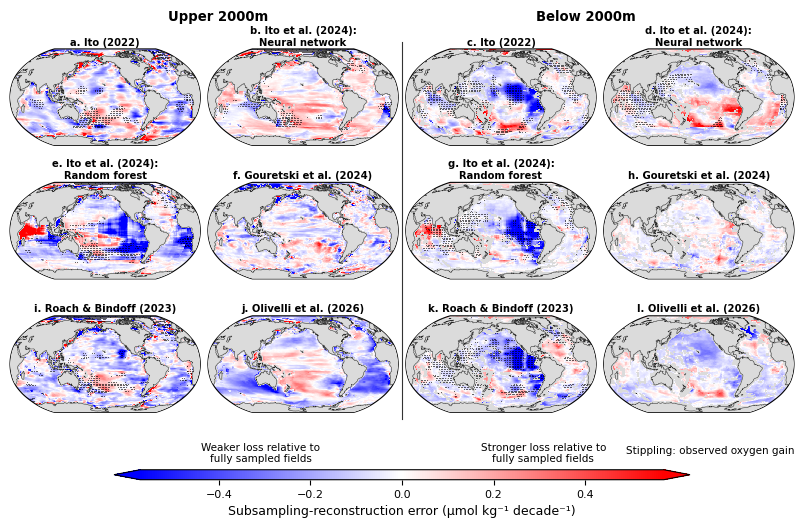

In [2]:
main()
